In [6]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats # for statistical tests

In [7]:
# display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

In [8]:
df = pd.read_csv(r"C:\Data science work\Projects\ab_testing_project\data\marketing_AB.csv")

df.head(5)

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


In [9]:
df.drop(columns=['Unnamed: 0'], inplace = True )

In [10]:
df.head()

,user id,test group,converted,total ads,most ads day,most ads hour
0,1069124,ad,False,130,Monday,20
1,1119715,ad,False,93,Tuesday,22
2,1144181,ad,False,21,Tuesday,18
3,1435133,ad,False,355,Tuesday,10
4,1015700,ad,False,276,Friday,14


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   user id        588101 non-null  int64
 1   test group     588101 non-null  str  
 2   converted      588101 non-null  bool 
 3   total ads      588101 non-null  int64
 4   most ads day   588101 non-null  str  
 5   most ads hour  588101 non-null  int64
dtypes: bool(1), int64(3), str(2)
memory usage: 23.0 MB


In [12]:
df.shape

(588101, 6)

In [13]:
df.columns

Index(['user id', 'test group', 'converted', 'total ads', 'most ads day',
       'most ads hour'],
      dtype='str')

In [14]:
df['converted'].dtypes

dtype('bool')

In [15]:
df['user id'].duplicated().sum()

np.int64(0)

**All users should be in only 1 group**

 If any user appears in both:

Experiment is flawed

We must remove them

In [16]:
df.groupby('user id')['test group'].nunique().value_counts()

test group
1    588101
Name: count, dtype: int64

**Roughly balanced (not necessarily 50/50, but not extreme)**

In [17]:
df['test group'].value_counts(normalize=True)

test group
ad     0.96
psa    0.04
Name: proportion, dtype: float64

**This tells:**

How many converted vs not

Whether dataset is skewed

In [18]:
df["converted"].value_counts()

converted
False    573258
True      14843
Name: count, dtype: int64

**Conversion Rate Comparison**

Does the ad actually improve conversion?

In [19]:
conversion_rates = df.groupby('test group')['converted'].mean()

print(conversion_rates)

test group
ad     0.025547
psa    0.017854
Name: converted, dtype: float64


In [20]:
ad_rate = conversion_rates['ad'] # conversion rate for the ad group
psa_rate = conversion_rates['psa'] # conversion rate for the psa group

uplift = (ad_rate - psa_rate) / psa_rate* 100 # calculate the percentage uplift

print(f'ad conversion Rate:{ad_rate:.2f}')
print(f'psa conversion Rate:{psa_rate:.2f}')
print(f"Uplift: {uplift:.2f}%")

ad conversion Rate:0.03
psa conversion Rate:0.02
Uplift: 43.09%


**Hypothesis Testing (REAL DECISION)**

“Is this difference real or just random chance?”

we will use:

👉 Z-test for proportions

In [21]:
from statsmodels.stats.proportion import proportions_ztest

#conversions for both groups
conversions = [ 
    df[df['test group']== 'ad']['converted'].sum(), # number of conversions in the ad group
    df[df['test group']== 'psa']['converted'].sum()  # number of conversions in the psa group
]

# total users in both groups

n_observations =[
    df[df['test group'] == 'ad']['converted'].count(), # total users in the ad group
    df[df['test group'] == 'psa']['converted'].count() # total users in the psa group
]

# perform the z-test

z_stat, p_value = proportions_ztest(conversions, n_observations) # perform the z-test

print(f'z-stat:{z_stat:}') 
print(f'p_value:{p_value:}')

z-stat:7.3700781265454145
p_value:1.7052807161559727e-13


**Confidence Interval (CI)**

🎯 Goal

Instead of just saying:

“Conversion increased by 1%”

We say:

“The true increase is likely between X% and Y%”

**🧠 What Confidence Interval Does**

It answers:

“What is the range of the true effect in the population?”

**📊 Concept (keep it simple)**

You are estimating:

👉 Difference in conversion rates
(ad − psa)

But that value has uncertainty.

CI gives:

Lower bound
Upper bound

In [22]:
# conversion rate 

p1 = ad_rate 
p2 = psa_rate

#sample size for both groups

n1 = df[df['test group'] == 'ad'].shape[0]
n2 = df[df['test group']== 'psa'].shape[0]

#difference in conversion rates

diff = p1 - p2

#standard error of the difference

se = np.sqrt((p1*(1-p1)/n1) + (p2*(1-p2)/n2))

# 95% confidence interval

z = 1.96

lower = diff - z * se

upper  = diff + z * se

print (f'difference:{diff:}')
print(f'95% confidence interval:[{lower:},{upper:}]')

difference:0.007692453192201517
95% confidence interval:[0.00595090043017032,0.009434005954232714]


**Segmentation Analysis**

🎯 Goal

Answer:

“Where does the ad perform best?”

Not just if it works—but where it works.

**🧠 Why this matters**

Companies don’t care:

“Ads increase conversion”

**They care:**

“Ads work best on Tuesday evenings for mobile users”

👉 That’s actionable insight

**Compare ad vs psa for each day**

Identify:

Best performing day

Worst performing day

**Day-wise Performance**

In [23]:
day_analysis = df.groupby(['most ads day','test group'])['converted'].mean().unstack('test group')

print(day_analysis)

test group          ad       psa
most ads day                    
Friday        0.022465  0.016303
Monday        0.033241  0.022559
Saturday      0.021307  0.013996
Sunday        0.024620  0.020595
Thursday      0.021637  0.020230
Tuesday       0.030440  0.014448
Wednesday     0.025356  0.015759


**Add uplift**

*Best Performing Day → Tuesday*

Uplift = 110.7%

Ad: 3.04 % vs PSA: 1.44 %

*Strong Days:*

Wednesday → 60.9% uplift

Saturday → 52.2% uplift

Monday → 47.3% uplift

*Worst Day → Thursday*

Uplift = 7%

In [24]:
# add uplift %

day_analysis['uplift_%'] = (day_analysis['ad'] - day_analysis['psa']) / day_analysis['psa'] * 100 

print(day_analysis)

test group          ad       psa    uplift_%
most ads day                                
Friday        0.022465  0.016303   37.797113
Monday        0.033241  0.022559   47.355277
Saturday      0.021307  0.013996   52.235413
Sunday        0.024620  0.020595   19.542962
Thursday      0.021637  0.020230    6.953197
Tuesday       0.030440  0.014448  110.690914
Wednesday     0.025356  0.015759   60.894460


**✨Ad effectiveness peaks mid-week, particularly on Tuesday and Wednesday, while showing minimal impact on Thursday, suggesting user engagement patterns significantly influence conversion behavior.**

**Hour-wise Performance**

In [25]:
hour_analysis = df.groupby(['most ads hour','test group'])['converted'].mean().unstack('test group')

print(hour_analysis)

test group           ad       psa
most ads hour                    
0              0.019213  0.000000
1              0.013434  0.000000
2              0.007570  0.000000
3              0.010425  0.011236
4              0.015850  0.000000
5              0.021563  0.000000
6              0.023174  0.000000
7              0.018482  0.008439
8              0.019861  0.010622
9              0.019529  0.010815
10             0.021840  0.013468
11             0.022469  0.014556
12             0.024139  0.016990
13             0.025063  0.016590
14             0.028575  0.016051
15             0.029845  0.025164
16             0.030893  0.028055
17             0.028537  0.020246
18             0.027470  0.025177
19             0.026809  0.024514
20             0.030274  0.017642
21             0.029175  0.022202
22             0.026455  0.016358
23             0.022970  0.012924


**Add uplift:**

**Some PSA values may be:**

Very small Or zero

👉 This can cause:

Very high or infinite uplift

🔥 Best Reliable Hours

*🥇 Hour 7 (7 AM)*

Uplift ≈ 119%

*🥈 Hour 8–10*

Strong uplift (60–85%)

*🥉 Hour 14 (2 PM)*

Uplift ≈ 78%

*🟢 Hour 20–23 (Evening/Night)*

Consistent strong uplift (~60–77%)

In [26]:
# add uplift 
hour_analysis['uplift_%'] = (hour_analysis['ad']-hour_analysis['psa'])/hour_analysis['psa'] * 100

print(hour_analysis)

test group           ad       psa    uplift_%
most ads hour                                
0              0.019213  0.000000         inf
1              0.013434  0.000000         inf
2              0.007570  0.000000         inf
3              0.010425  0.011236   -7.220077
4              0.015850  0.000000         inf
5              0.021563  0.000000         inf
6              0.023174  0.000000         inf
7              0.018482  0.008439  119.017510
8              0.019861  0.010622   86.976325
9              0.019529  0.010815   80.567128
10             0.021840  0.013468   62.162920
11             0.022469  0.014556   54.364538
12             0.024139  0.016990   42.075246
13             0.025063  0.016590   51.075446
14             0.028575  0.016051   78.024395
15             0.029845  0.025164   18.600742
16             0.030893  0.028055   10.115891
17             0.028537  0.020246   40.954471
18             0.027470  0.025177    9.107606
19             0.026809  0.024514 

**❌ Worst Hour → Hour 3**

Negative uplift (~ -7%)

*👉 Interpretation:*

Ads may actually hurt performance 

Very low engagement time

*⚠️ Low Impact Hours:*

16–19 → ~9–10% uplift

***HOUR-WISE FINAL INSIGHT***

**✨“Ad performance is strongest during morning (7–10 AM) and evening hours (8–11 PM), while showing minimal or negative impact during early morning hours, indicating strong time-dependent user responsiveness.”**

***💥 FINAL BUSINESS INSIGHT***

*Combine everything:*

**“The A/B test reveals that ad-driven conversion improvements are statistically significant, with performance varying notably across time segments. Ads are most effective during mid-week (especially Tuesday) and peak user activity hours (morning and evening), suggesting that targeted ad scheduling could significantly improve campaign efficiency.”**

# **Visualization (Python)**

**📊 1. Conversion Rate Comparison**

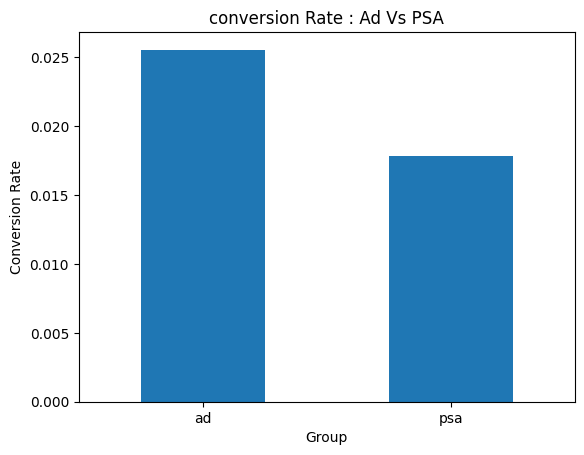

In [27]:
conversion_rates.plot(kind = 'bar')

plt.title('conversion Rate : Ad Vs PSA')

plt.ylabel('Conversion Rate')
plt.xlabel('Group')
plt.xticks(rotation =0)
plt.show()

**📊 2. Day-wise Performance**

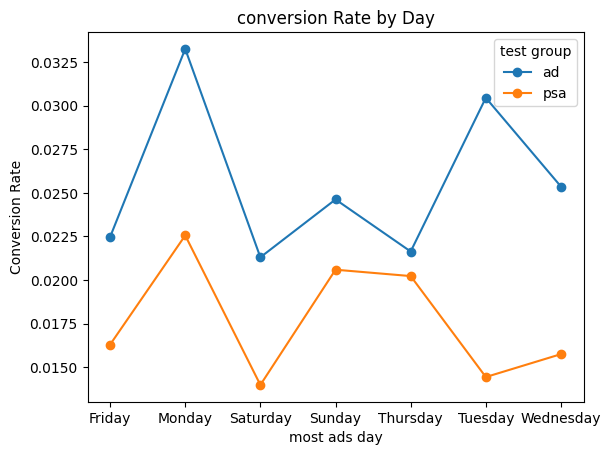

In [28]:
day_analysis[['ad' , 'psa']].plot(kind= 'line' , marker = 'o') 

plt.title('conversion Rate by Day')
plt.ylabel('Conversion Rate')
plt.show()


**📊 3. Hour-wise Performance**

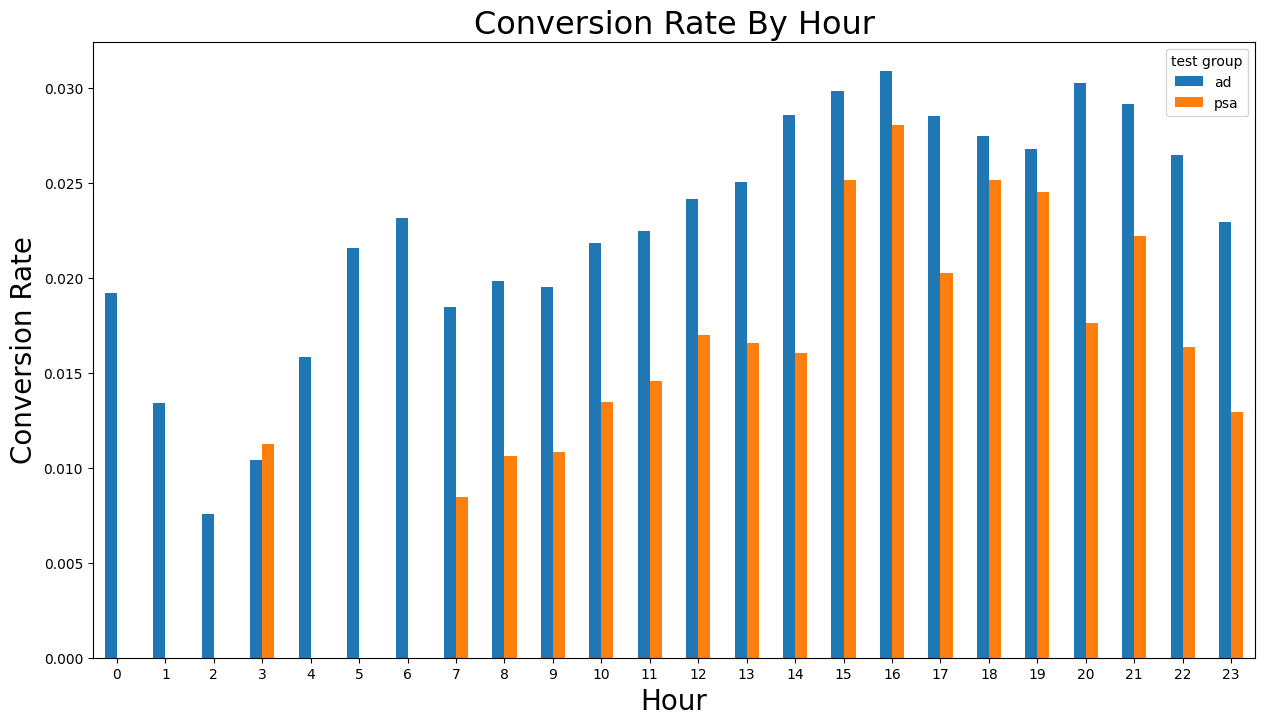

In [29]:

hour_analysis[['ad' , 'psa']].plot(kind = 'bar', figsize=(15,8))

plt.title('Conversion Rate By Hour',fontsize=23 )
plt.ylabel('Conversion Rate', fontsize = 20)
plt.xlabel('Hour', fontsize = 20)
plt.xticks(rotation = 0)

plt.show()


**📊 4. Uplift Visualization**

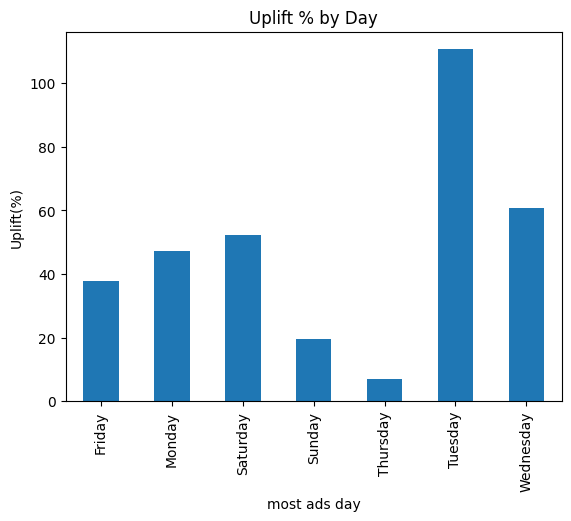

In [30]:
day_analysis['uplift_%'].plot(kind = 'bar')

plt.title('Uplift % by Day')
plt.ylabel('Uplift(%)')
plt.show()